In [310]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray95"),
    legend.box = "horizontal",
    legend.direction = "horizontal",
    legend.key.height = unit(0.15,"snpc"),
    legend.key.width  = unit(0.15,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 32),
    axis.text.x  = element_text(size = 28),
    axis.text.y = element_text(size = 28),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 24),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")
fig(20,12)

## 2. $\chi ^2$ o cómo se distribuyen las varianzas o desviaciones de la muestra


### 2.1 Introducción

Un problema que no vimos *nunca* es el asunto de cómo estimar $\sigma^2$ ó $\sigma$ a partir de una muestra. Es verdad que nuestra estrategia **siempre** fue calcular $\mathbf{s}$ con $n \rightarrow \infty$ y rezarle al santo de los grandes números (llamado San Bernoulli).

### 2.1.1 Planteo del problema o *"remembering you, standart deviation"*

Si alguien recuerda, o lo vió por ahí, la desviación estándar puede ser definida como:

\begin{eqnarray}
\sigma &=& \sqrt{\sum_{i} (x_i - \mu)^2 p(x_i)} \; \; \; \; (discreto) \label{esdd} \\
\sigma &=& \sqrt{\int_{-\infty}^{\infty} (x-\mu)^2 f(x) \; dx} \; \; \; \; (contínuo) \label{esdc} \\
\end{eqnarray}

con lo que viendo las ecs.(\ref{esdd} y \ref{esdc}) nos damos cuenta de algo muy importante:

* **La desviación estándar de la población sólo puede ser calculada si se conocen, adecuadamente, las funciones de distribución de densidad de probabilidad (caso contínuo) o la función de distribución de probabilidad (caso discreto), $\mathbf{p(x)}$ ó $\mathbf{f(x)}$.**

* **...nunca las conocemos...porque nunca tenemos el tiempo suficiente para medir infinitas veces...**

* **La estrategia, como siempre, saber dónde "viven" las versiones cimarronas de la desviación estándar, que es la *desviación estándar de la muestra*, que denominamos $S$** (nos intentamos comer la cola)


<img src="https://media.giphy.com/media/3oFzmdjqH15YebLQ52/giphy.gif" width="400" />

### 2.1.2 Distribución $\chi ^2$

La función densidad de probabilidad de $\chi ^2 _\nu$ (con $\nu$ grados de libertad) es:

$$f(x|\nu) = \dfrac{1}{\Gamma(\nu\,/\,2)\,  2^{\nu\,/\, 2}} \; x^{(\nu\,/\,2 -1)} \;\; \; exp\Big( -x\, /\, 2\Big)$$
donde:
* **$\nu$ son los grados de libertad de $\chi ^2$.**

  
* **$\Gamma$ es una versión real de la función factorial (que no hace falta conocer)**

  
* *La forma de obtener la distribución en R es **dchisq()** (para la función densidad de probabilidad), **rchisq()** (para generar randoms que cumplan esta distribución) y **qchisq()** para obtener los cuantiles a partir de las probabilidades (véalo por sus propios medios)*

* Valor medio de una variable aleatoria $X$ con distribución $\chi ^2$: $\langle X \rangle =  \nu$
* Varianza de una variable aleatoria $X$ con distribución $\chi ^2$: $Var(X) = 2\nu $

$\chi ^2 _\nu$ se ve como:

In [399]:
dchi <- data.frame(x = x <- seq(0,20,0.05), d = dchisq(x = x, df = 5));
gchisq <- ggplot(data = dchi, aes(x = x, y = d)) + geom_line() + ylab(TeX("$\\chi^2 _{\\nu = 5} \\; \\; (x)$")) + temajuan3

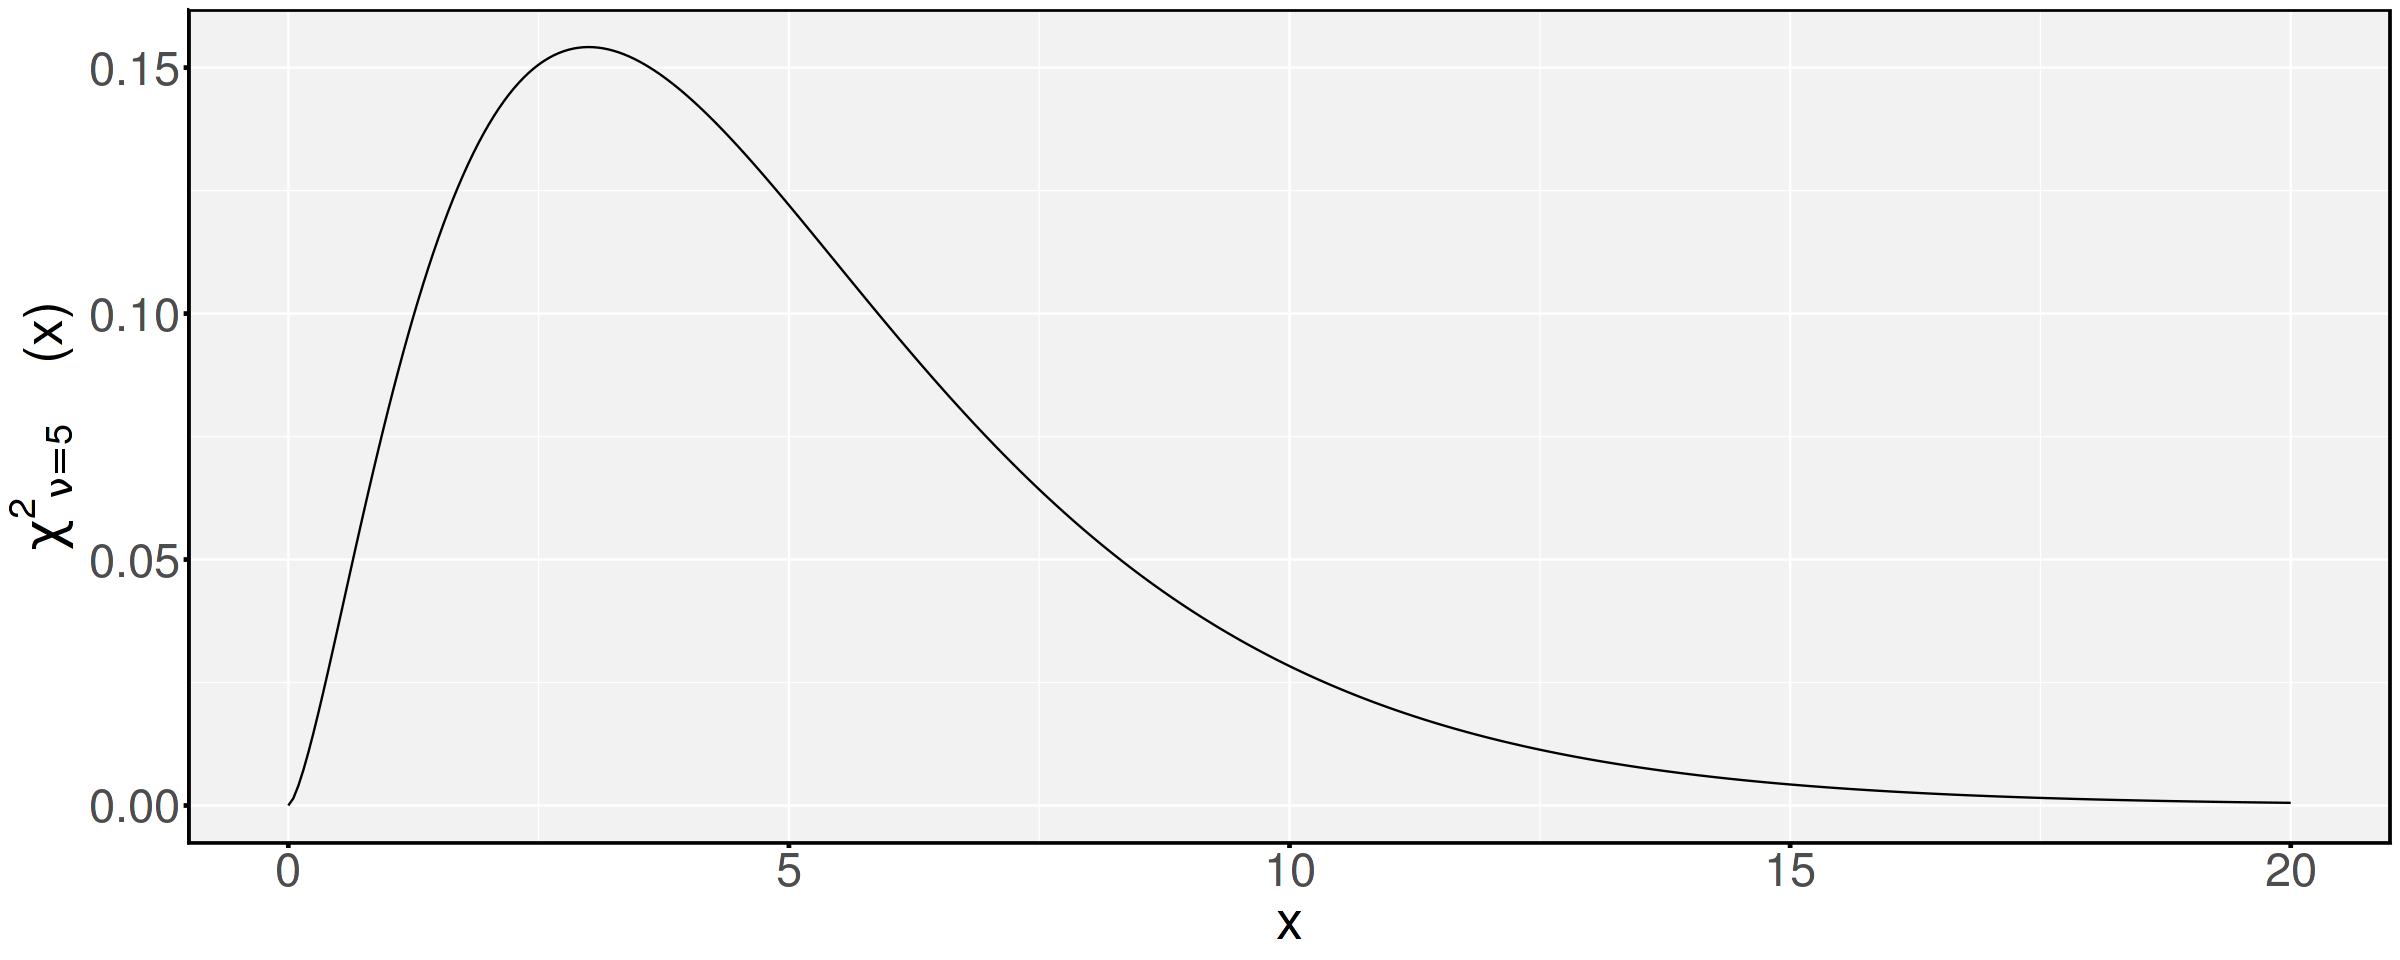

In [402]:
fig(20,8);show(gchisq)

+ Identifiquemos el valor medio de $X$ ¿coincide con la moda?


+ Identifiquemos la desviación estándar...¿cumple lo de $\mu \pm \sigma_X$ contiene $68 \%$ de probabilidades?

### 2.1.3 Definiendo el estadístico

**Cuando tenemos una muestra de n datos y no conocemos $\sigma$, podemos intentar con:**

$$\sqrt{\dfrac{\sum_{i} (x_i - \mu)^2}{n} }$$

pero claro, resulta que no conocemos la media $\mu$, con lo cual intentamos con la *desviación estándar de la muestra*:

$$s = \sqrt{\dfrac{\sum_{i} (x_i - \overline{x})^2}{n-1} }$$

donde en la ec. anterior el denominador pasa a $n-1$ porque la media fue calculada como una media muestral, restándole un grado de libertad. **Esta última fórmula es un estadístico (sólo hay que tener las variables y calcularlo...) conocido como *desviación estándar de la muestra*.**

También $s$ es un valor posible de una variable aleatoria, $S$: no es posible determinar $\sigma$ a partir de un conjunto de datos, pero podemos ver dónde vive $S$ y relacionarlo con $\sigma$.

### 2.2 Teorema

Hay un lindo teorema que dice:
***
***
  
<div style="text-align:center"><span style="color:red; font-family:Georgia; font-size:1.5em;">
"La distribución del estadístico  $Y = (n-1)S^2/\sigma^2$  es $\chi ^2$ con (n-1) grados de libertad."</span></div>
  
  
***
***
Lo que nos dice el teorema es ***dónde vive*** una colección infinita e idealizada de desviaciones estándar de la muestra, $s_i$.

Como siempre, sin pruebas por la complicación, pero al fin y al cabo tenemos lo que queremos:

* Cuando medimos, tenemos $x_1,x_2,x_3,...,x_n$. No conocemos nada, pero podemos calcular $\overline{x}$ (la media muestral) y $s$ (la desviación estándar de la muestra).

   * La media muestral vive en una distribución...que nos permite darle ***cotas de confianza a $\mu$***

   * La desviación estándar de la muestra, multiplicada y dividida por factores (el tamaño de la muestra y $\sigma$), vive en una distribución $\chi ^2$ (se lee *ji cuadrado* ó en versiones cimarronas anglofílicas, *chí cuadrado*).
   
   


### 2.3 Cómo se ve esto formalmente?

   
   Sabemos que una desviación estándar de la muestra vive  $\chi ^2_{\nu = n-1} \;(Y)$. Entonces:
   
   * Nos arreglamos con un ***nivel de confianza*** elegido por nosotros, al que llamamos $\alpha$.
   
   La probabilidad de que al muestrar $Y = (n-1)s^2\sigma^2$ quede en el intervalo que buscamos será de $(1-\alpha)$.
   
   $$P\Big(q_i < \dfrac{(n-1)s^2}{\sigma^2} < q_d\Big) = 1 - \alpha$$ 
   
     
donde $q_i$ y $q_d$ son los cuantiles a izquierda y a derecha de la distribución. Obvio: $F(q_d) - F(q_i) = 1-\alpha$.    
     

 Desde donde obtenemos: $$P\Big(\dfrac{(n-1)s^2}{q_d} < \sigma^2 < \dfrac{(n-1)s^2}{q_i} \Big) = 1- \alpha$$
 
 Calculando los valores de cuantiles a izquierda y derecha de $\sigma^2$ podemos obtener el **intervalo de confianza** que buscamos.

### 3. Ejemplo

Medimos $g$ un total de $n = 11$ veces.

In [403]:
set.seed(102); g <- rnorm(mean = 9.8, sd = 0.1, n = 11)

Tenemos entonces 11 valores. La media y la desviación estándar (ambas muestrales), son:

In [404]:
cat(bold("La media muestral mm.g = ", mean(g)))
cat(bold("\n s de la muestra es  s.g = ", s <- sd(g)))

La media muestral mm.g =  9.88256203927618
 s de la muestra es  s.g =  0.0936433631641257

Entonces queremos estimar intervalos de confianza para $\sigma$.

* Como medimos $n = 11$ veces, el teorema que escribimos nos asegura que $Y \in \chi^2_{\nu = 11-1 = 10}$ 

Y listo:

1. Tenemos un valor de s.

1. Tenemos la distribución desde la cual está muestreado.

   * Elegimos un intervalo de confianza de $1 - \alpha = 0.95 = 95\%$

   * Elegimos $F(q_i) = 0.025 = 2.5\%$ y $F(q_d) = 0.975 = 97.5\%$

In [314]:
qi <- qchisq(p = 0.025, df = 10); #cuantil izquierdo
qd <- qchisq(p = 0.975, df = 10); #cuantil derecho

Ahora calculamos las cantidades que delimitan $\sigma$, usando raíces cuadradas en la última ecuación:
$$
P\Big(\sqrt{\dfrac{(n-1)s^2}{q_d}} < \sigma < \sqrt{\dfrac{(n-1)s^2}{q_i}} \Big) = 1- \alpha
$$

como:

In [315]:
sigma.min = sqrt( (11-1)*s^2 / qd); #límite inferior para sigma
sigma.max = sqrt( (11-1)*s^2 / qi); #límite inferior para sigma

#imprimimos
cat(bold(sigma.min, "< sigma <", sigma.max, ", con 95% de probabilidades"))

0.06543021391556 < sigma < 0.164337879509336 , con 95% de probabilidades

### 4. Una función que haga esto ameo

En vez de hacerlo una y otra vez, mejor hacerlo una función. Esto se puede guardar en `int.sigma.R` y luego se carga en el código como `source("c:/Directorio/int.sigma.R")`.

In [316]:
int.sigma <- function(datos, nivel.confianza){
    
nu <- length(datos)-1 #grados de libertad de chisq

s <- sd(datos) #s de los datos

alpha.sim <- 1-nivel.confianza   
if(alpha.sim < 0 | alpha.sim > 1){return("El nivel de confianza debe estar entre 0 y 1")}

#cuantiles simétricos
qi <- qchisq(p = alpha.sim/2, df = nu); #cuantil izquierdo
qd <- qchisq(p = 1-alpha.sim/2, df = nu); #cuantil derecho

#calculamos los límites de la ec.
sigma.min = sqrt( (nu)*s^2 / qd); #límite inferior para sigma
sigma.max = sqrt( (nu)*s^2 / qi); #límite inferior para sigma

#resultado de la función en un vector    
return(c(sigma.min,sigma.max))    
}

In [317]:
sd(g)

[1] 0.09364336

In [405]:
int <- int.sigma(g,0.99); int

[1] 0.05900361 0.20168197

In [319]:
int.sigma(g,1.1); #no funciona por el nivel de confianza fuera de rango

[1] "El nivel de confianza debe estar entre 0 y 1"

In [320]:
int.sigma(g,1); #la certeza absoluta arruina la vida para estimar parámetros y para muchas cosas más

[1]   0 Inf

In [321]:
int.sigma(g,0); # ningún nivel de confianza nos da sd(g)
#con probabilidad P = 0, sigma será sd(g)...no sirve de nada

[1] 0.09688606 0.09688606

### 5. Nivel de confianza, explicado

El nivel de confianza no garantiza (al igual que cualquier otro test estadístico de enfoque frecuentista) que $\sigma$ esté entre los valores calculados. Dice que va a estar entre los valores calculados con cierta probabilidad. 

En el enfoque frecuentista de la teoría de probabilidad esto nos dice que:

* En el proceso aleatorio que estamos viendo, si sacamos muestras de tamaño $n$, vamos a tener un 95% de las veces a $\sigma$ dentro del intervalo calculado.

Podemos ver esto por medio de PRNG (generadores de pseudo aleatorios):

In [322]:
m <- 60; #cantidad de puntos

sigma <- 1; #sigma desde donde muestreamos
nivconf <- 0.5 #nivel de confianza para el test
n <- 11 #tamaño muestra
s <- vector(mode = "numeric", length = m)
sigma.min <- vector(mode = "numeric", length = m)
sigma.max <- vector(mode = "numeric", length = m)
contiene <- vector(mode = "integer", length = m)
for(i in 1:m){
s[i] <- sd(muestra <- rnorm(sd = sigma, n = 11))   
sigma.min[i] <- int.sigma(muestra,nivconf)[1]; sigma.max[i] <- int.sigma(muestra, nivconf)[2];
contiene[i] <-  ((sigma - s[i]) > 0 & (sigma.max[i]) > sigma ) |  ((sigma - s[i]) < 0 & (sigma.min[i]) < sigma ) 
}
nf <- data.frame(i = 1:m, s = s, sigma.min = sigma.min, sigma.max = sigma.max, cont <- contiene)
    
#rm(s, sigma.min, sigma.max, contiene, i)

In [407]:
min <- round(min(s-sigma.min), 1); max <- round(max(s + sigma.max),2);  
gnf <- ggplot(data = nf, aes(x = i, y = s)) +
geom_pointrange(aes(ymin = sigma.min, ymax = sigma.max, colour = as.factor(cont))) +
scale_colour_manual(values = c("0" = "Gray45", "1" = "Deepskyblue3"),
                labels = list(TeX("$No \\; contiene \\; a \\; \\sigma}$"),TeX("$Contiene \\; a \\; \\sigma}$"))) + 
geom_hline(yintercept = sigma, colour = "Deepskyblue4") +
scale_y_continuous(breaks = c(0.5,sigma,1.5), labels = c(0.5,TeX("$\\sigma = 1$"), 1.5)) + 
xlab("Muestra número") + ylab("s") + ggtitle("s para diferentes muestras de la misma distribución.") + 
temajuan3 + theme(legend.title = element_blank(),panel.background = element_rect(fill = "Gray95"),
                 legend.position = c(0.5,0.925),
                  legend.background = element_rect(color = "Black", size = 0.5),
                 legend.text = element_text(margin = margin(l = 0, r = 20, t = 10, b = 10) ) )

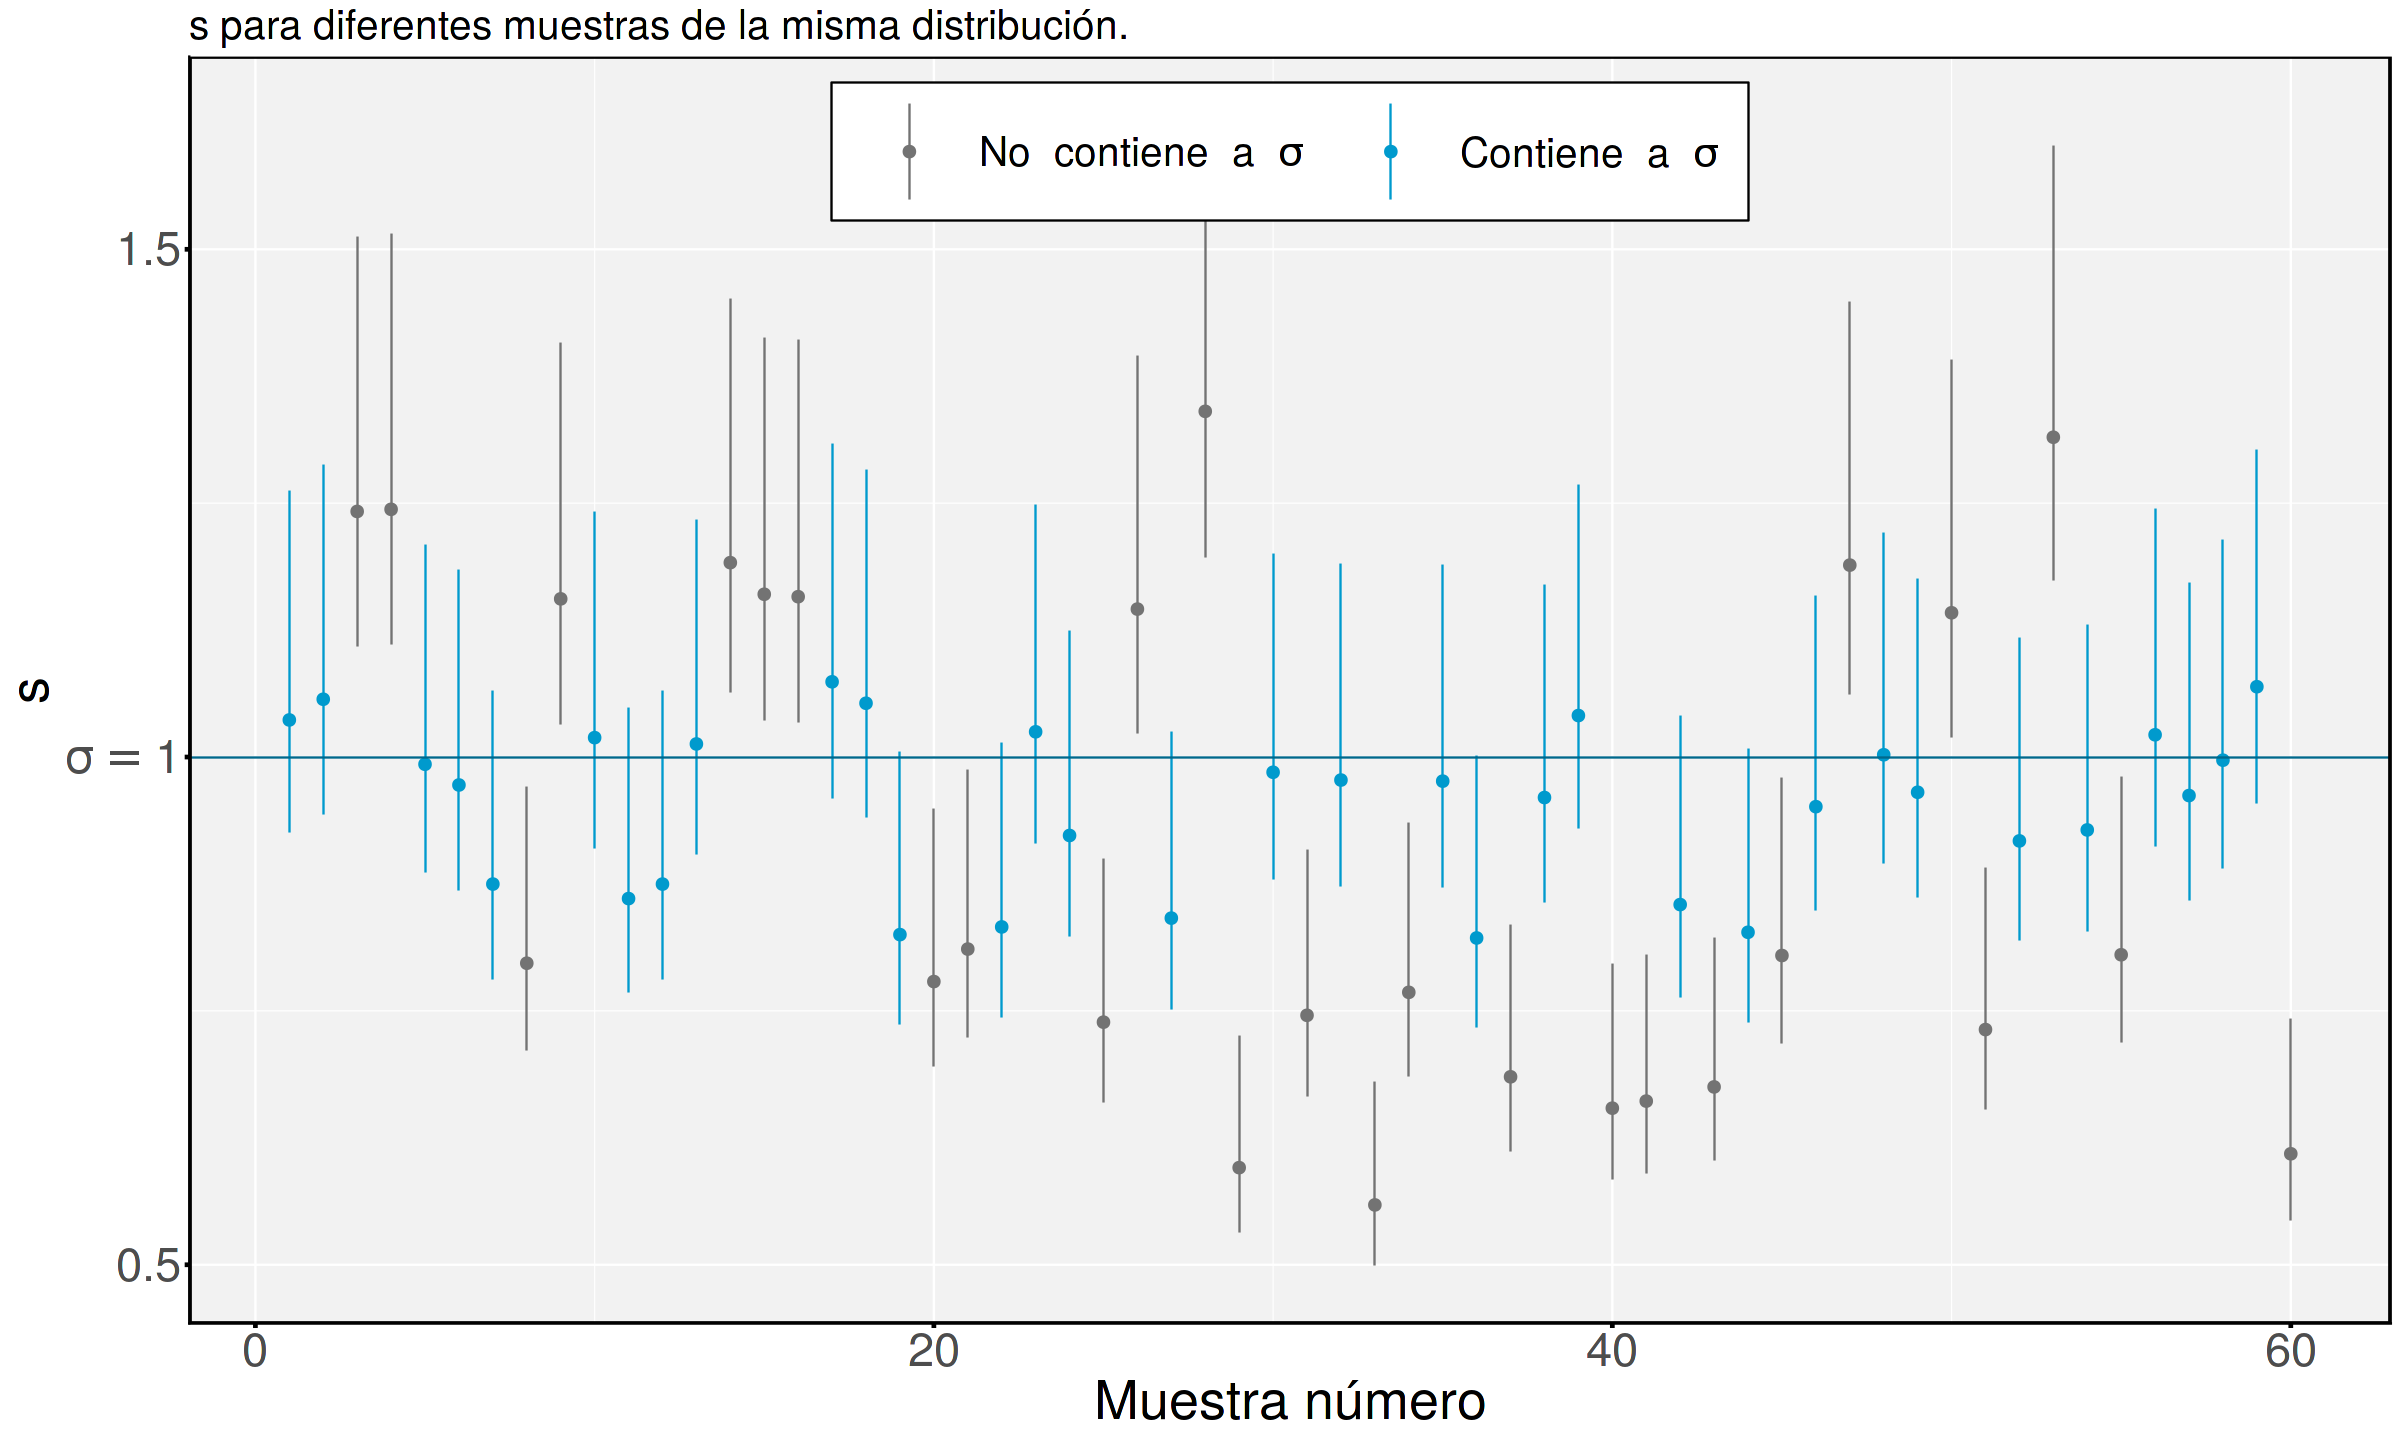

In [408]:
fig(20,12); show(gnf)

Si contamos, **N° puntos grises / N° puntos totales $\approx \alpha$**

y, obviamente

**N° puntos celestes / N° puntos totales $\approx 1- \alpha$**

En este caso:

In [325]:
1-nivconf;
sum(nf$cont)/length(nf$cont);
( length(nf$cont) - sum(nf$cont)) /length(nf$cont);


[1] 0.5

[1] 0.55

[1] 0.45

Si hacemos crecer el número de puntos a infinito entonces los cocientes van a ser exactamente lo que deberían ser...bueno, se entiende ya.

### 6. Cuestiones del tamaño de la muestra

El tamaño de la muestra está muy relacionado con el ancho de $\chi^2$, por lo que calcular $s$ con $n = 4$ medidas no es lo mismo que calcularlo con $n = 1000$ medidas, cosa que ya sabíamos.

Para eso, cargamos un archivito con los valores del módulo de $g$, como la clase anterior.

In [412]:
setwd("/home/juan/Documentos/Docencia/fexpi/2020/NTB/6.meansdTLC/denuevo/") #indica un nuevo directorio
g <- read.csv(file = "g.csv", sep = "\t", header = F); g <- g$V1;

El tamaño de la muestra es: 5150. La desviación estándar es $0.00978617627897517 m/s^2$.

In [414]:
int.sigma(g, 0.95); #intervalo para sigma con nivel de confianza del 95%,

[1] 0.009600778 0.009978929

A este nivel de confianza, $\sigma$ tiene determinadas 3 cifras decimales...

* Ahora vamos a sacar unas  doscientas muestras al azar, cada una de tamaño $n$, de la muestra de los 5150 valores y vamos a calcular las desviaciones estándar de cada muestra.

* Lo vamos a hacer para valores de $n = 2,3,4,5,6,....,100$ y vamos a ver un gráfico de $s_n / s_{5150} ~ s/\sigma $

Queremos ver cómo varía la desviación estándar de la muestra respecto del tamaño de la muestra.

In [415]:
n <- 50; m <- 200
desv <- vector(mode = "numeric", length = n*m)
tamagno <- vector(mode = "integer", length = n*m)
for(i in 1:n){
    for(j in 1:m){
    muestra <- sample(x = g, size = i+1, replace = T)
    desv[(i -1)*m+j] <- sd(muestra)
    tamagno[(i -1)*m+j]<- i+1
    }

}

sn <- data.frame(s = desv, n = tamagno)

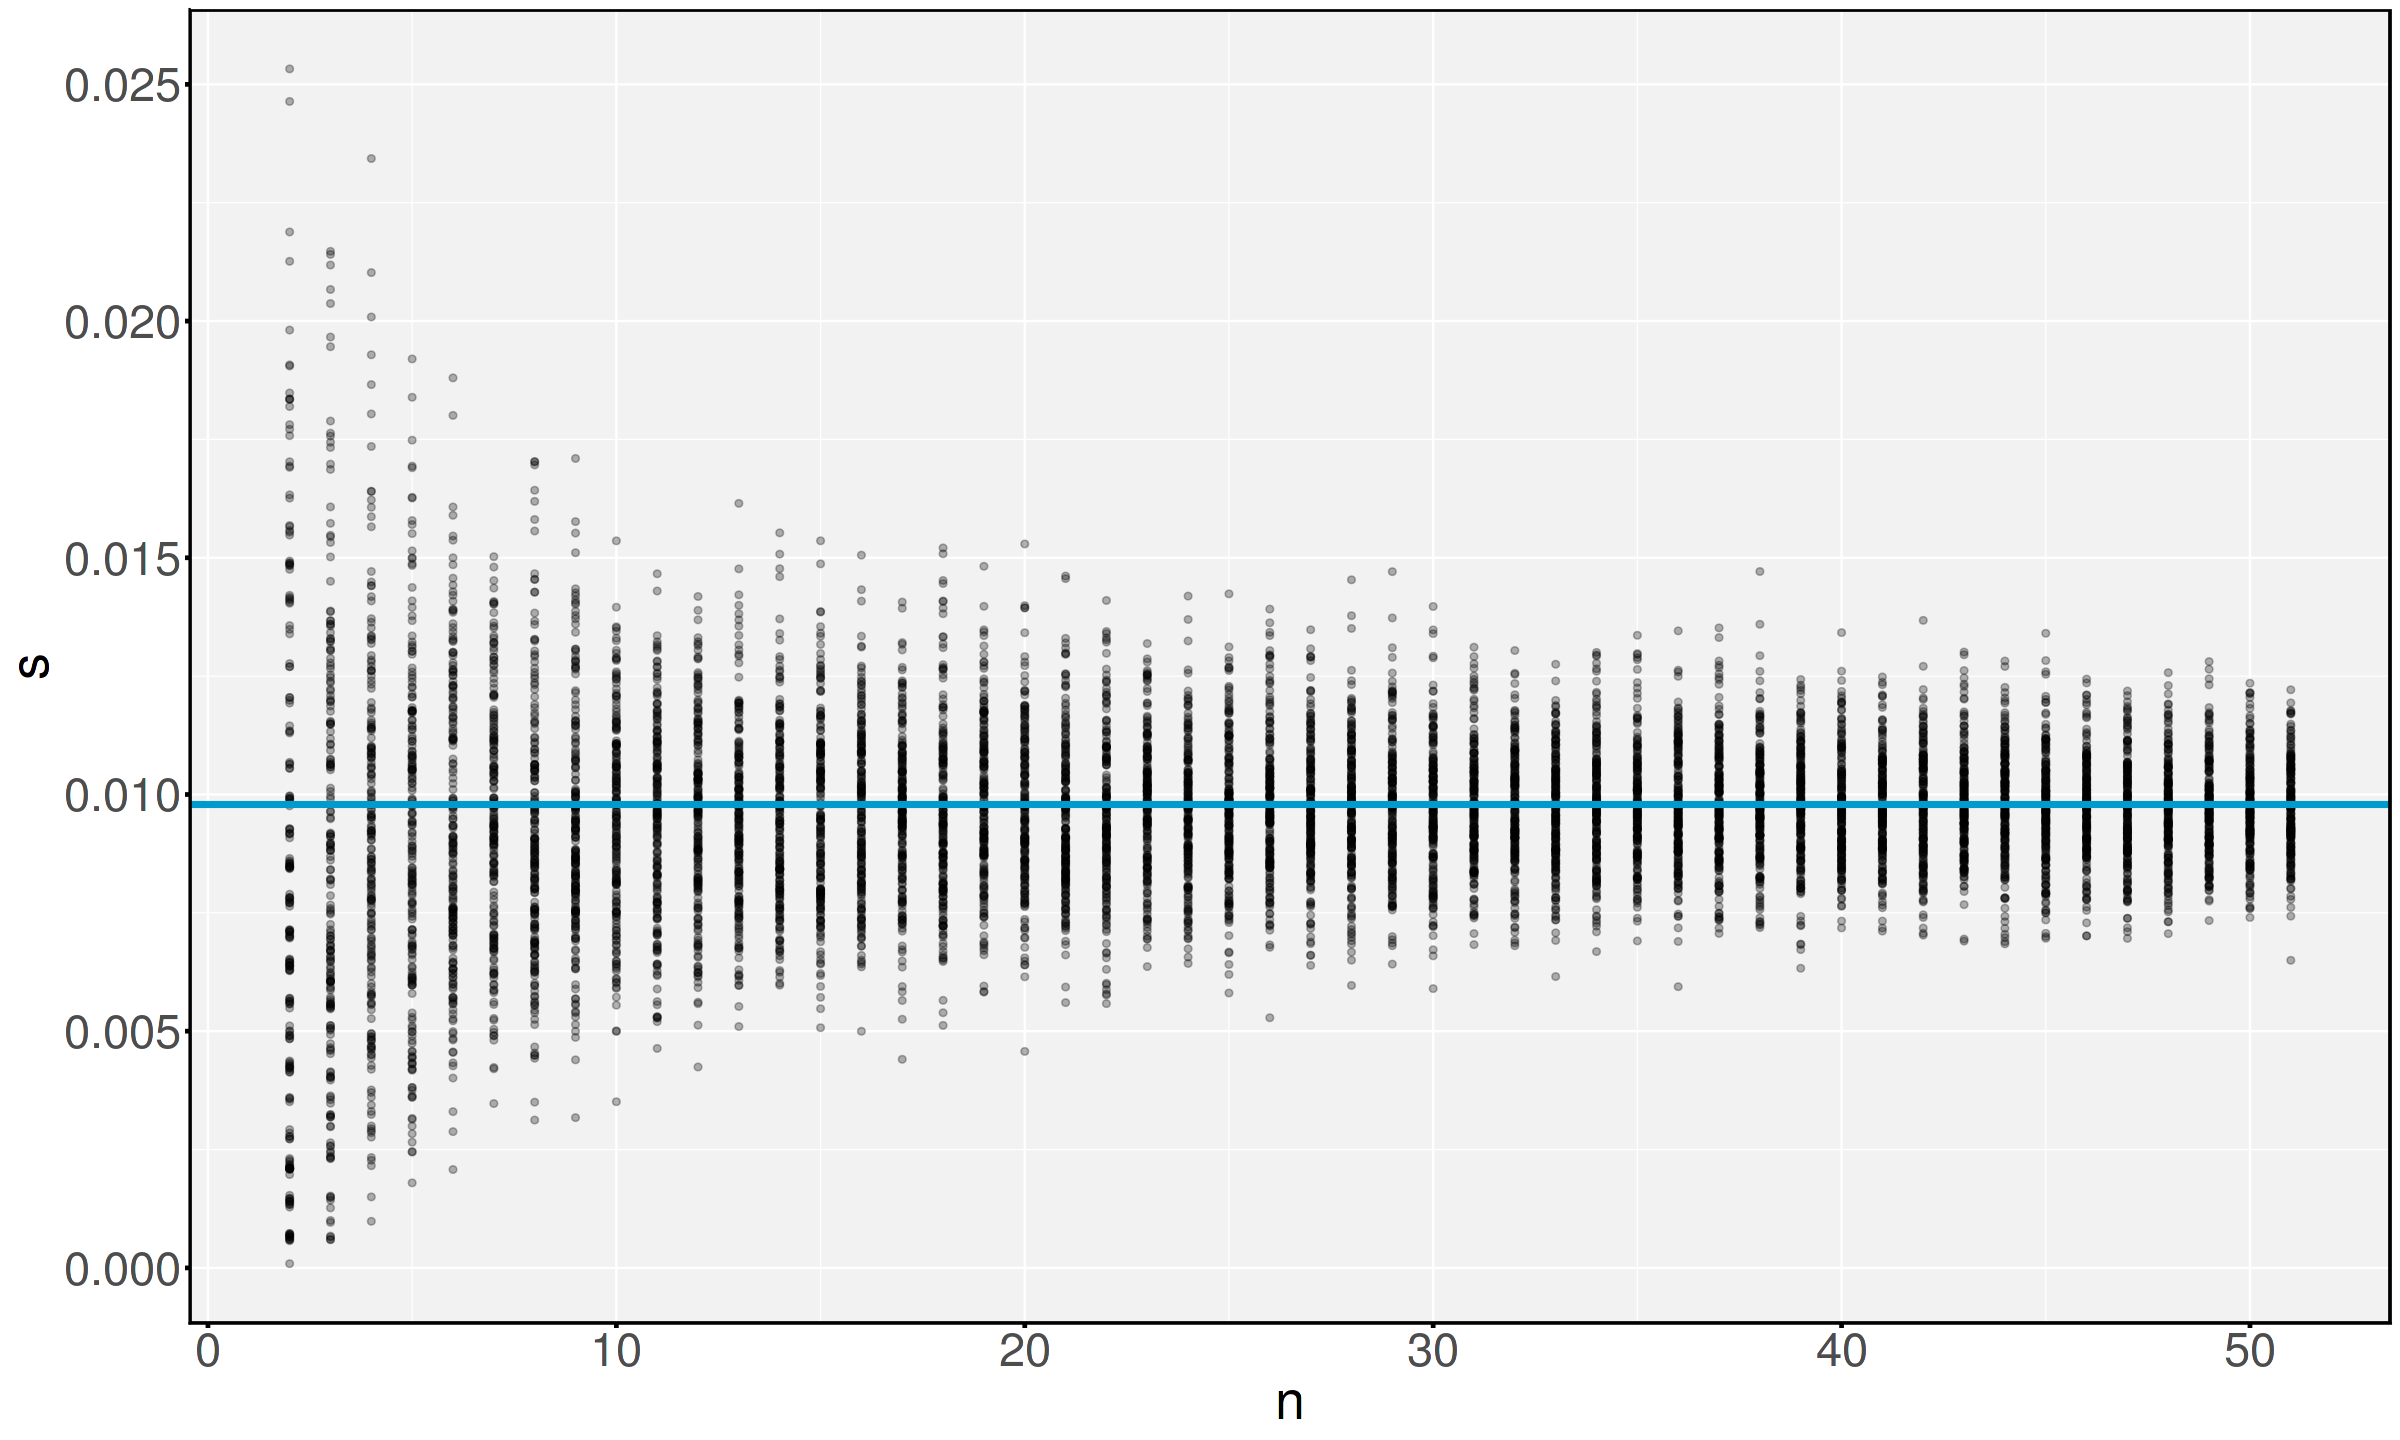

In [416]:
gsn <- ggplot(data = sn, aes(x = n, y = s)) + geom_point(alpha = 0.3) + 
geom_hline(yintercept = sd(g), lwd = 1.5,colour = "Deepskyblue3") + temajuan3; show(gsn)

En el gráfico vemos que:

* Las dispersiones están ***centradas*** en la línea azul, que es muy parecida a $\sigma$: $s(n = 5150)$. Esto quiere decir que $s$ es **un estimador *no sesgado* de $\sigma$**, es decir, el valor medio $\langle (n-1)S^2/\sigma^2 \rangle = (n-1) \Rightarrow \langle S^2/\sigma^2 \rangle = 1 \Rightarrow \langle S \rangle = \langle \sigma \rangle$. 



* La dispersión de S bajan a medida que aumenta $n$: $\sqrt{Var((n-1)S^2/\sigma^2) }= \sqrt{2(n-1)}$

***A retomar desde el principio (Debord)***

Retomando la idea de probabilidad, la idea es generar cierto conocimiento sobre el *error relativo* de la desviación estándar de la muestra. En efecto, podemos reescribir la variable de la probabilidad como:


$$P\Bigg(\sqrt{\dfrac{q_i}{(n-1)}} < \dfrac{s}{\sigma} < \sqrt{\dfrac{q_d}{(n-1)} }\Bigg) = 1- \alpha$$

Lo que tenemos en la ec. anterior es una idea de cómo son los intervalos de confianza para $s/\sigma$, es decir, una especie valor que mide cuánto podemos equivocarnos en la estimación de $\sigma$ si medimos el estadístico $s$ en una muestra de tamaño $n$.

Si escribimos $\sigma ~ s(n = 5150)$ en la ec. anterior, y rehacemos el gráfico agregando cotas superiores $y_+(n) = \sqrt{\dfrac{q_d}{(n-1)} }$ y cotas inferiores  $y_-(n) = \sqrt{\dfrac{q_i}{(n-1)}}$, tenemos:

In [421]:
alpha = 0.05


y.mas <- vector(mode = "numeric", length = n)
y.menos <- vector(mode = "numeric", length = n)

qplus <- vector(mode = "numeric", length = n)
qmin <- vector(mode = "numeric", length = n)
for(i in 2:(n+1)){
#cuantiles
q <- qchisq(p =c(alpha/2, 1-alpha/2), df = i-1 )
qplus[i-1] <- q[2]; qmin[i-1] = q[1];
#intervalos de chi^2 en términos de s/sigma
y.mas[i-1] <- sqrt( q[1]/ (i-1) )
y.menos[i-1] <- sqrt( q[2]/ (i-1) )
}

In [422]:
gsn2 <- ggplot()+
geom_point(aes(x = sn$n, y = sn$s/sd(g))) +
geom_hline(yintercept = 1, colour = "Deepskyblue3") +
geom_ribbon(aes(x = c(2:(length(y.menos)+ 1)), ymin = y.menos, ymax = y.mas), fill = "Deepskyblue4", alpha = 0.3 ) + 
ylab(TeX("$\\approx s/ \\sigma$")) + xlab("n (tamaño muestra)") + 
temajuan3

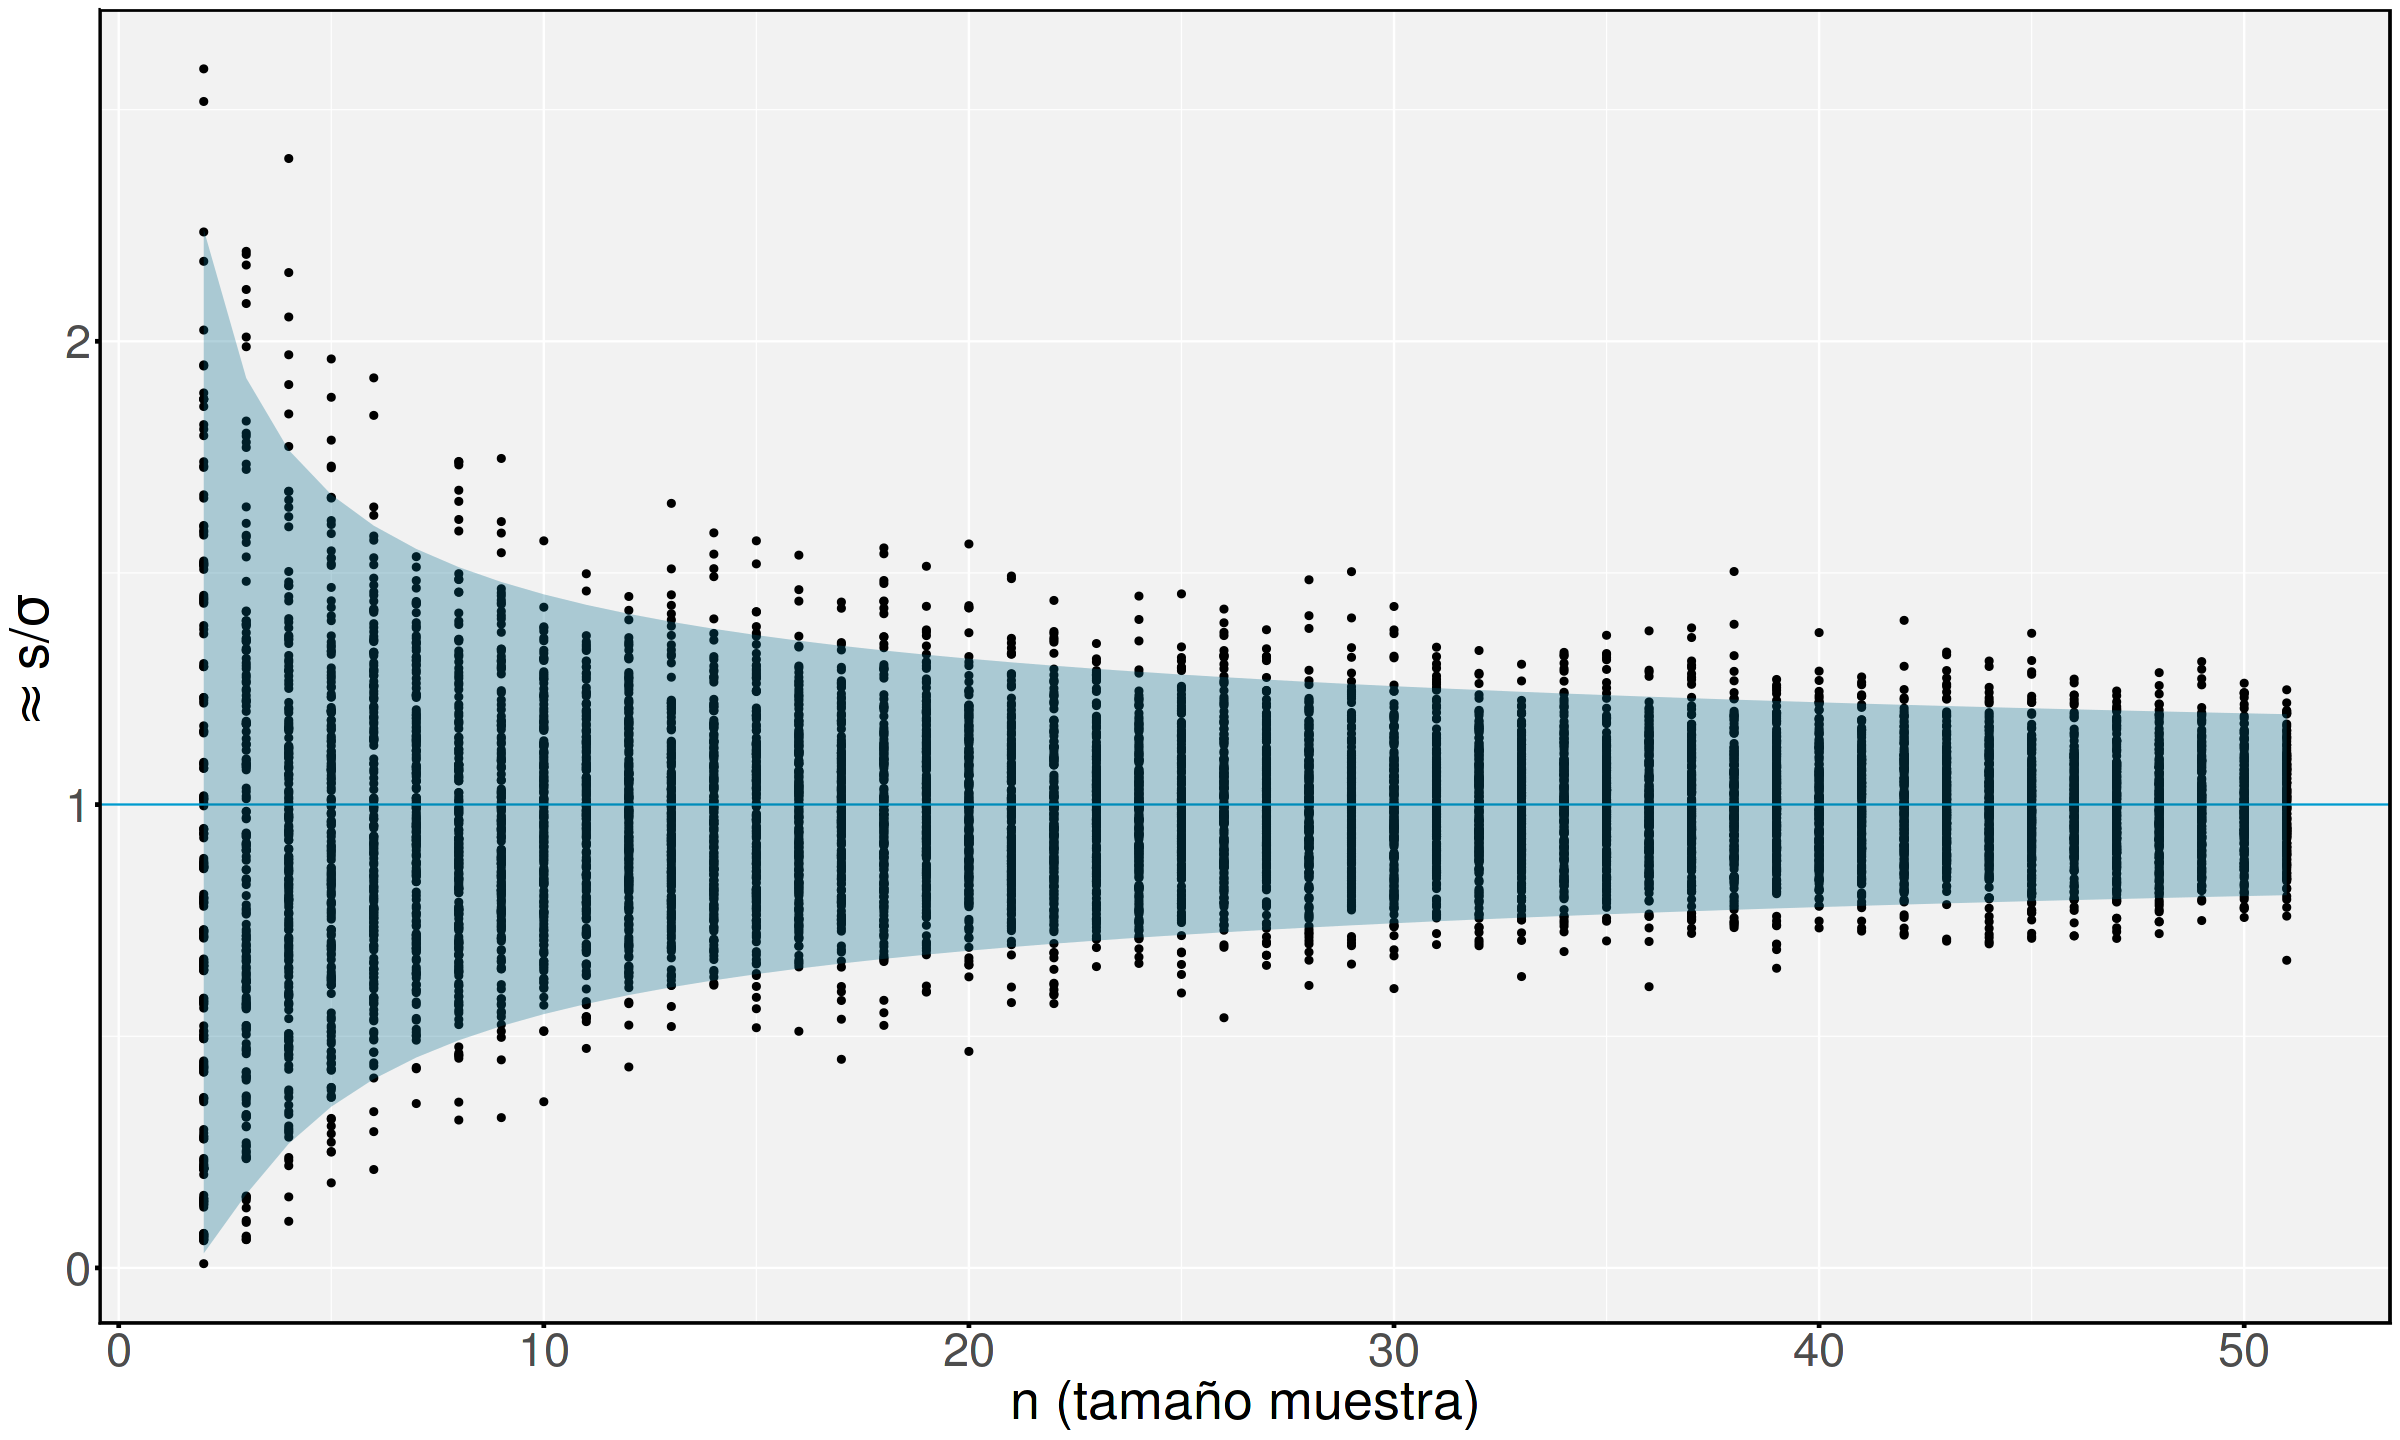

In [423]:
show(gsn2)

Como siempre, si contamos la cantidad de puntos que están afuera de el intervalo de confianza...nos tendrían caer cerca de $\alpha = 0.05$:

In [424]:
yp <- rep(y.mas, each = m); ym <- rep(y.menos, each = m)

alpha.a.mano <- sum((sn$s/sd(g) < yp) | (sn$s/sd(g) > ym))/nrow(sn)
cat(bold("alpha similar a", alpha.a.mano))

alpha similar a 0.0559

### Cerrando

Al estimar $\sigma$ con $s$ tenemos lo de siempre:

* No hay otra forma, pero no le pegamos.

* Depende del tamaño de la muestra que utilicemos.

* Podemos hacer estimaciones de qué *q